# Iris Flower Classification 

## Importing relevant libraries 

In [167]:
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

# Machine learning
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

## Loading the dataset

In [5]:
data_init = sklearn.datasets.load_iris()

In [6]:
data_init

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

Information on the data shows that it has 4 attributes:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

In [8]:
data = np.array(data_init["data"])

## Exploratory Data Analysis 

In [10]:
# Checking the shape
data.shape

(150, 4)

The data has 150 items and 4 attributes. As described earlier, it has 50 in each i.e setosa, Versicolour, and Virginica.

In [12]:
# Checking data types
data.dtype

dtype('float64')

In [123]:
## using initial feature names
feature_names = data_init.feature_names
feature_names

data_frame = pd.DataFrame(data, columns=feature_names)
## missing values
data_frame.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

### Making a copy for manipulation 

In [15]:
data_arr = data.copy()

In [16]:
data_split = data_arr.reshape(3, 50, 4)

In [17]:
setosa = data_split[0]
versicolour = data_split[1]
virginica = data_split[2]

### Making pandas dataframes for setosa, versicolour and viriginica

In [19]:
setosa_df = pd.DataFrame(setosa, columns=feature_names)
versicolour_df = pd.DataFrame(versicolour, columns=feature_names)
virginica_df =pd.DataFrame(virginica, columns=feature_names)

In [20]:
setosa_df["target"] = "setosa"
versicolour_df["target"] = "versicolour"
virginica_df["target"] = "virginica"

df = pd.concat([setosa_df,versicolour_df,virginica_df])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
45,6.7,3.0,5.2,2.3,virginica
46,6.3,2.5,5.0,1.9,virginica
47,6.5,3.0,5.2,2.0,virginica
48,6.2,3.4,5.4,2.3,virginica


### Descriptive Statisitcs of Setosa

In [22]:
for x in feature_names:
    print("========================================")
    print(setosa_df[x].describe(include=all))

count    50.00000
mean      5.00600
std       0.35249
min       4.30000
25%       4.80000
50%       5.00000
75%       5.20000
max       5.80000
Name: sepal length (cm), dtype: float64
count    50.000000
mean      3.428000
std       0.379064
min       2.300000
25%       3.200000
50%       3.400000
75%       3.675000
max       4.400000
Name: sepal width (cm), dtype: float64
count    50.000000
mean      1.462000
std       0.173664
min       1.000000
25%       1.400000
50%       1.500000
75%       1.575000
max       1.900000
Name: petal length (cm), dtype: float64
count    50.000000
mean      0.246000
std       0.105386
min       0.100000
25%       0.200000
50%       0.200000
75%       0.300000
max       0.600000
Name: petal width (cm), dtype: float64


#### Key insights on the Iris Setosa Descriptives
- The sepal length and setal width are normally distributed with the mean equaling to the median.
- The petal length and width are just slightlyy right skewed given that the mean is slighly larger than the median. This shows a small variation towards larger values

### Descriptive Statisitcs of Versicolour

In [25]:
for x in feature_names:
    print("========================================")
    print(versicolour_df[x].describe(include=all))

count    50.000000
mean      5.936000
std       0.516171
min       4.900000
25%       5.600000
50%       5.900000
75%       6.300000
max       7.000000
Name: sepal length (cm), dtype: float64
count    50.000000
mean      2.770000
std       0.313798
min       2.000000
25%       2.525000
50%       2.800000
75%       3.000000
max       3.400000
Name: sepal width (cm), dtype: float64
count    50.000000
mean      4.260000
std       0.469911
min       3.000000
25%       4.000000
50%       4.350000
75%       4.600000
max       5.100000
Name: petal length (cm), dtype: float64
count    50.000000
mean      1.326000
std       0.197753
min       1.000000
25%       1.200000
50%       1.300000
75%       1.500000
max       1.800000
Name: petal width (cm), dtype: float64


#### Key insights on the Iris Versicolour Descriptives
- It is general for all that the mean is slighly larger than the median signifying that there are slighly more larger values than the mean and the attributes are only mildly right skewed.

### Descriptive Statisitcs of Virginica

In [28]:
for x in feature_names:
    print("========================================")
    print(virginica_df[x].describe(include=all))

count    50.00000
mean      6.58800
std       0.63588
min       4.90000
25%       6.22500
50%       6.50000
75%       6.90000
max       7.90000
Name: sepal length (cm), dtype: float64
count    50.000000
mean      2.974000
std       0.322497
min       2.200000
25%       2.800000
50%       3.000000
75%       3.175000
max       3.800000
Name: sepal width (cm), dtype: float64
count    50.000000
mean      5.552000
std       0.551895
min       4.500000
25%       5.100000
50%       5.550000
75%       5.875000
max       6.900000
Name: petal length (cm), dtype: float64
count    50.00000
mean      2.02600
std       0.27465
min       1.40000
25%       1.80000
50%       2.00000
75%       2.30000
max       2.50000
Name: petal width (cm), dtype: float64


#### Key insights on the Virginica Descriptives
- The petal length and width along with the sepal width show a highly normally distributed distribution with the mean and median nearly identical.
- The sepal length on the other hand shows a different deviation from the rest where by it had a lower mean as compared to the median signifying left skewness and hence drawn more to the lower values.

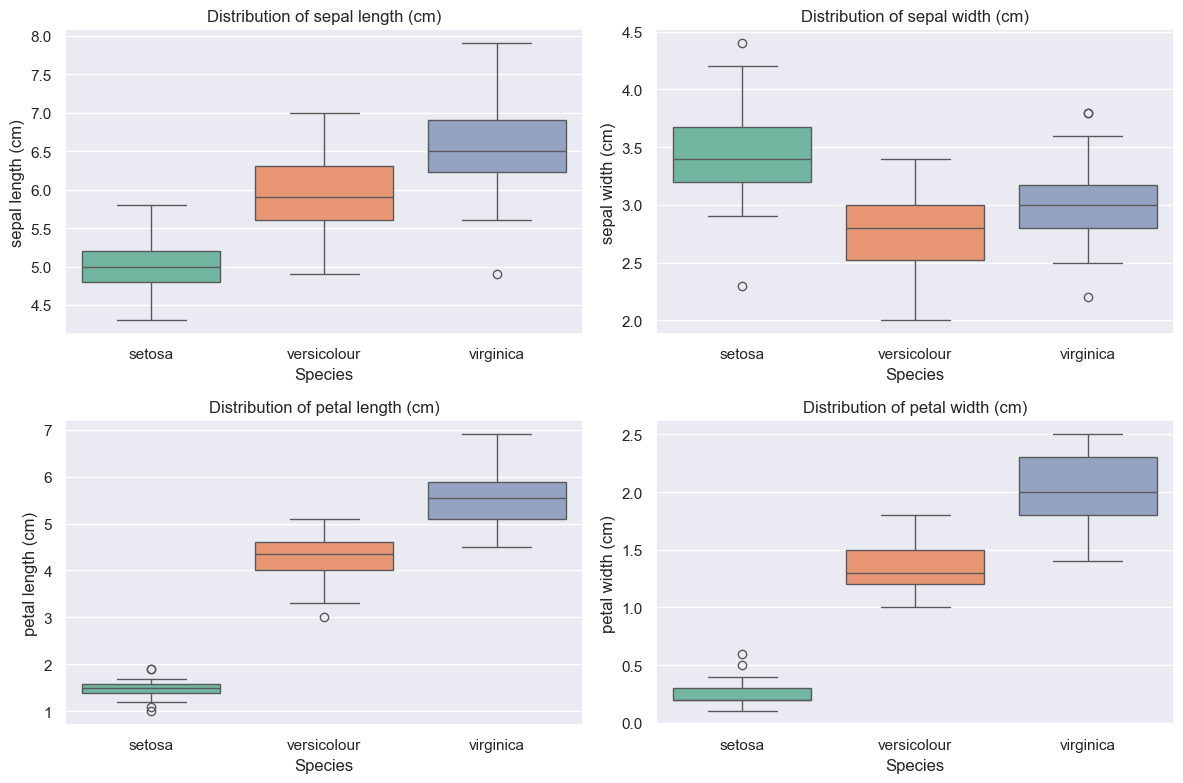

In [108]:
plt.figure(figsize=(12, 8))

for idx, feature in enumerate(feature_names, 1):
    plt.subplot(2, 2, idx)
    sns.boxplot(x='target', y=feature, data=df, hue='target' ,palette='Set2')
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Species')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

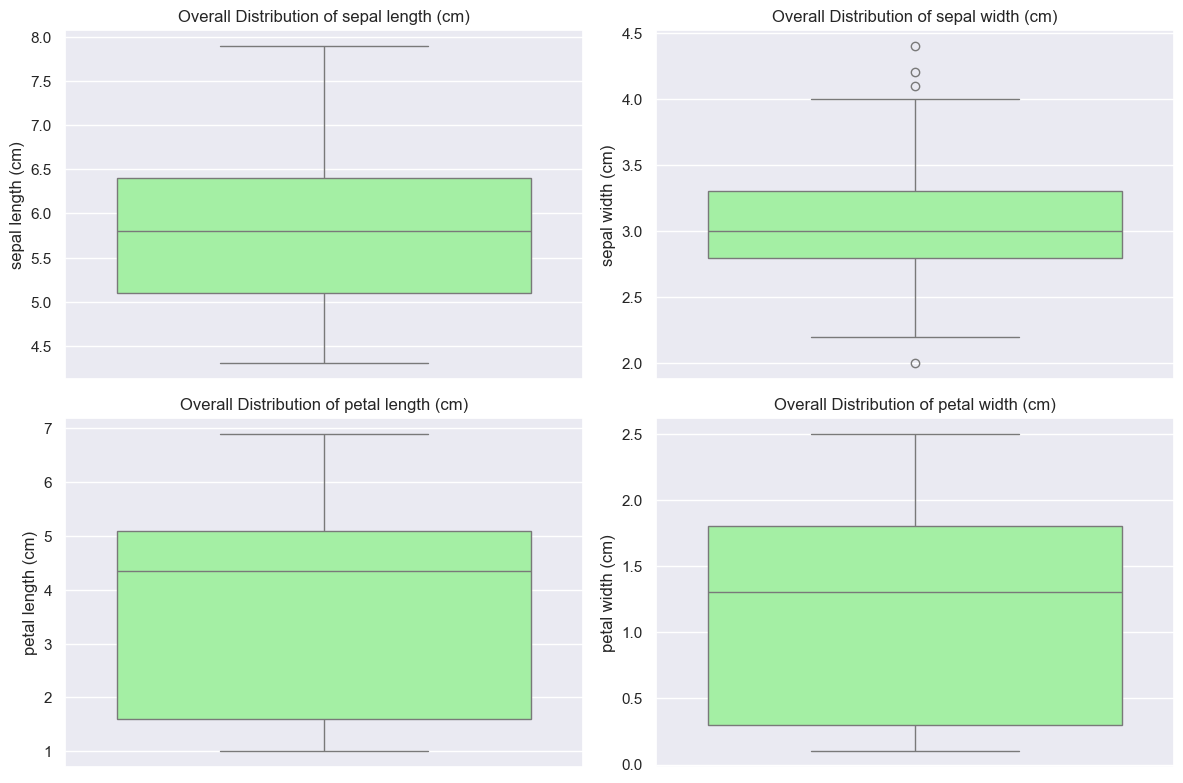

In [118]:
plt.figure(figsize=(12, 8))

for idx, feature in enumerate(feature_names, 1):
    plt.subplot(2, 2, idx)
    sns.boxplot(y=df[feature], color='palegreen')
    plt.title(f'Overall Distribution of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

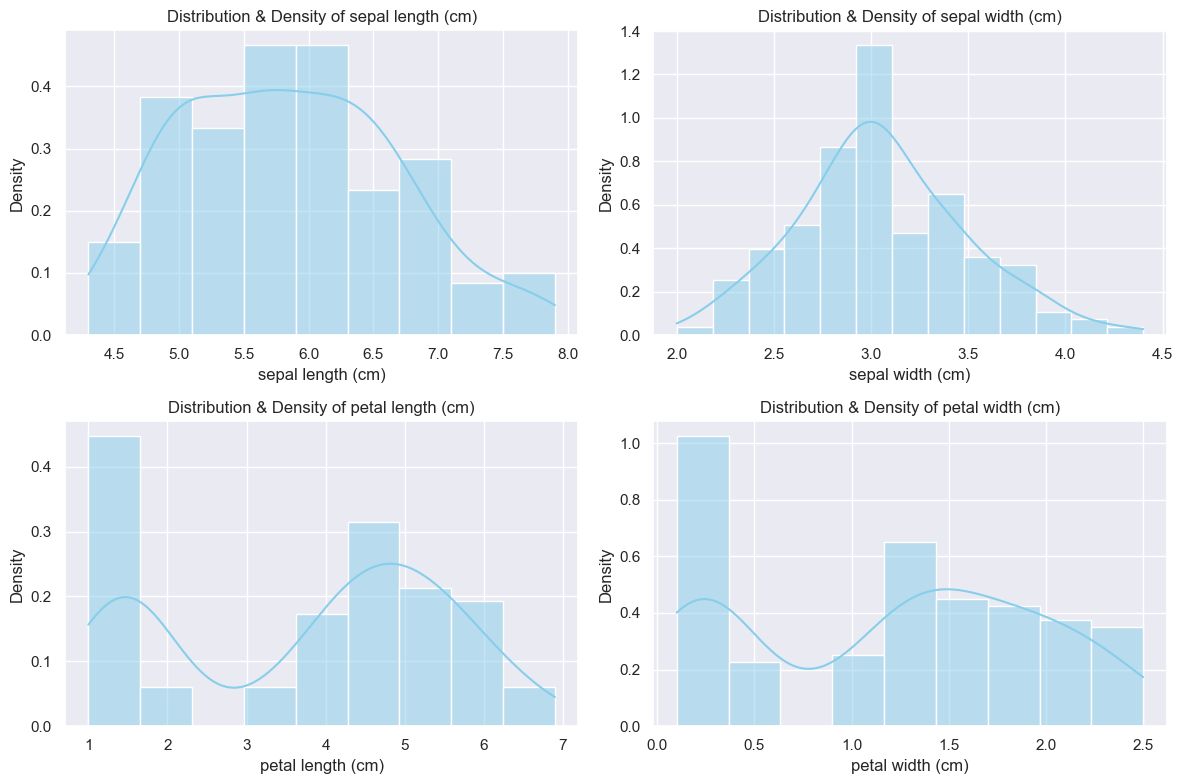

### Descriptive statistics of the entire dataframe

In [125]:
data_frame.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


- Petal width is very highly dispersed as compared to the rest. It is then followed by Sepal length, Petal width and Sepal Width which is the least dispersed.
- The mean of petal length is also smaller than the median showing 

## Visualizations 

### Pairplot with points colored by species

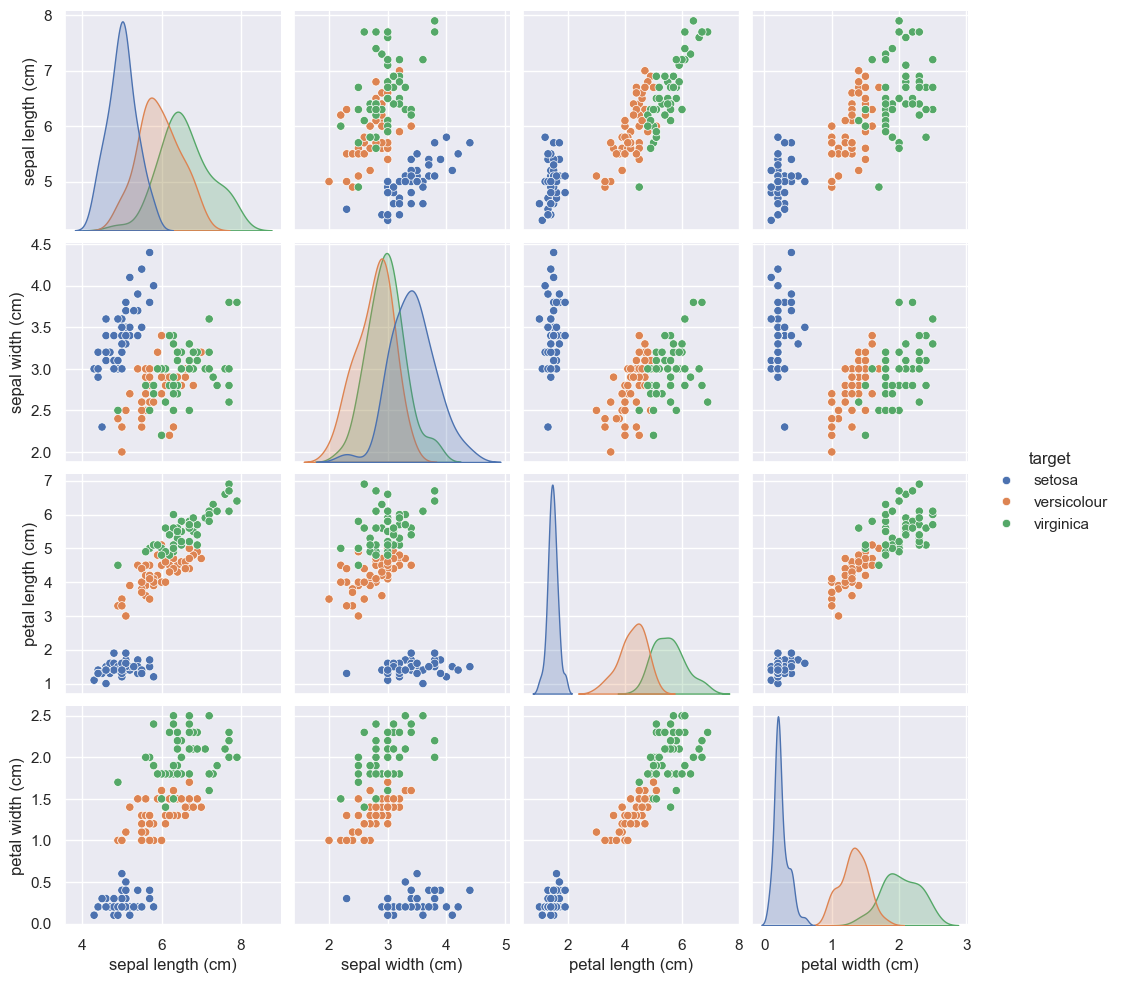

In [32]:
# Create pairplot with points colored by species
sns.pairplot(df, hue='target')
plt.show()

#### Key Insights
- The Iris setosa always forms a separate cluster from the other 2 which often overlap at a point.
- The petal length and petal width have a strong positive linear correlation which can be used as a differentiator between these 2.
- Since sepal length and sepal width are highly overlapping, it signifies a that they are less distinct predictors on their own.

## Feature selection 

In [35]:
corr_matrix = df.drop(columns=["target"]).corr()
corr_matrix

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


Text(0.5, 1.0, 'Iris Feature Correlation Matrix')

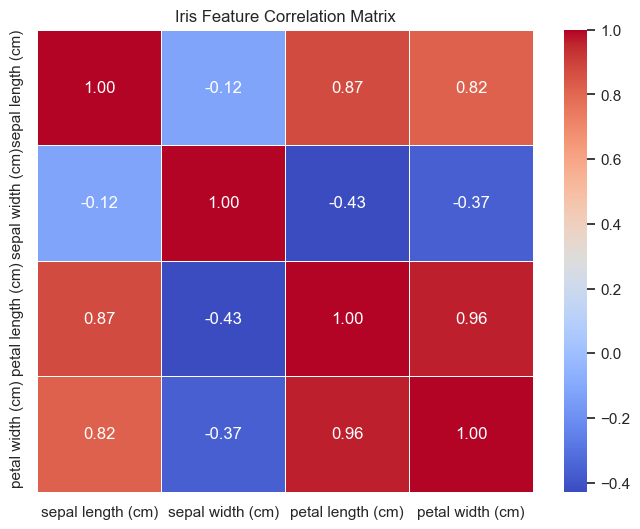

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Iris Feature Correlation Matrix")

### Points to base on
- The petal length and petal width provide the least overlap and hence the highest discrimination power. There is zero overlap with setosa completely. The virginica and vericolour have minimal overlap and clear boundaries. This is in addition to the strong correlation (0.96) showing a significant positive allignment thereby introducing redundancy and are a sign of multicollinearity.
- The sepal length and sepal width provide the least discrimination given the high overlap between versicolour and virginica where the points mix up thoroughly together hence a simple model may struggle to get a clear difference between the two. One can be retained to capture non redundant signal
### Way forward
- Petal length and petal width are the top 2 features to choose from.
    - Petal length is chosen as a primary feature given that it provides the highest discriminating power for setosa with zero overlap.
- Sepal width is chosen as the secondary feature given that it has a lower correlation with petal length as compared to sepal length. This helps to capture the non redundant information without risking high multicollinearity.

## Training and Testing Data Split (80/20 rule) 

In [39]:
# allocating train and test set
X = df[["petal length (cm)", "sepal width (cm)"]]
y = df["target"]

In [40]:
# reproducibility at 256 and 1:1:1 proportion in sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=256, stratify=y
)

In [41]:
# Model instances
models = {
    "LogisticRegression" : LogisticRegression(random_state=256),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=3),
    "Decision Tree" : DecisionTreeClassifier(random_state=256),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=256)
}

### Classification Report Generation

In [74]:
# Training, predicting, and getting evaluation matrix

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculating metrix
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {c}" for c in model.classes_], 
        columns=[f"Predicted {c}" for c in model.classes_]
    )

    results.append({"Model": name, 
                    "Accuracy Score": acc,
                    "Balanced Accuracy" : bal_acc
                   })

    print(f"---{name} - Classification Report---")
    print(classification_report(y_test, y_pred))
    print(f"---{name} - Confussion Matrix---")
    print(cm_df)
    print("-"*60)

---LogisticRegression - Classification Report---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
 versicolour       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

---LogisticRegression - Confussion Matrix---
                    Predicted setosa  Predicted versicolour  \
Actual setosa                     10                      0   
Actual versicolour                 0                      9   
Actual virginica                   0                      1   

                    Predicted virginica  
Actual setosa                         0  
Actual versicolour                    1  
Actual virginica                      9  
------------------------------------------------------------
---K-Nearest Neighbors - Classification Rep

## Results summary table based on accuracy 

In [45]:
output = pd.DataFrame(results).sort_values(by="Balanced Accuracy", ascending=False)
output.reset_index(drop=True, inplace=True)
output

,Model,Accuracy Score,Balanced Accuracy
0,K-Nearest Neighbors,0.966667,0.966667
1,LogisticRegression,0.933333,0.933333
2,Random Forest,0.933333,0.933333
3,Decision Tree,0.833333,0.833333


## Best Performing Model with Justification on the 2 attributes chosen
K-Nearest Neighbors has the highest score both in plain accuracy and the balanced accuracy. This makes it the best model. It is followed by the Logistic Regression, Random Forest and then the Decision Tree algorithms.


# Other ideas to test whether the multicollinearity tradeoff sacrifices predictive power

- Using the 2 attributes under the disguise of multicollinearity is not sufficient given the fact that the problem is evident in linear models like the logistic model and not on the non linear ones like the KNN, Naive Bayes, Decision Trees and ensembles like Random Forest.
- Given the fact that the variances are large for petal lengths as compared to those of sepal width chosen, the petal length dominates the sepal width regardless of whether they are in the same units. This needs us to standardize the attributtes to avoid this. The next cell shows the difference in variances.
- Another issue is that we are using a random state of 256 which can be out of lack and hence there is need for running with several states and averaging to get a better more rounded answer.

In [127]:
data_frame.agg(["var"])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
var,0.685694,0.189979,3.116278,0.581006


## Testing the tradeoff wiseveral states 

In [165]:
# setting 40 seeds
seeds = range(40)

# Setting pairs in a dictionary 
options = {
    "petal length + sepal width": ["petal length (cm)", "sepal width (cm)"],
    "petal length + petal width": ["petal length (cm)", "petal width (cm)"]
}

seed_results = []

for pair_name, fits in options.items():
    for name, model in models.items():
        for random_seed in seeds:
            X_r = df[fits]
            y_r = df["target"]
            X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=random_seed, stratify=y_r)
            model.fit(X_tr,y_tr)
            pred = model.predict(X_te)
            seed_results.append({
                "Feature Pair" : pair_name,
                "Model Choice" : name,
                "seed":random_seed,
                "Balanced Accuracy": balanced_accuracy_score(y_te, pred),
                "Accuracy Score": accuracy_score(y_te, pred)
            })
seed_df = pd.DataFrame(seed_results)
summary_df = (
    seed_df.groupby(["Feature Pair", "Model Choice"])[["Accuracy Score", "Balanced Accuracy"]]
    .mean()
)

summary_df = summary_df.sort_values(by="Accuracy Score", ascending=False)

summary_df

Accuracy Score  \
Feature Pair               Model Choice                          
petal length + petal width LogisticRegression         0.965833   
                           K-Nearest Neighbors        0.962500   
                           Random Forest              0.958333   
petal length + sepal width LogisticRegression         0.951667   
                           K-Nearest Neighbors        0.948333   
petal length + petal width Decision Tree              0.945000   
petal length + sepal width Random Forest              0.938333   
                           Decision Tree              0.925000   

                                                Balanced Accuracy  
Feature Pair               Model Choice                            
petal length + petal width LogisticRegression            0.965833  
                           K-Nearest Neighbors           0.962500  
                           Random Forest                 0.958333  
petal length + sepal width LogisticRegression            0.951667  
                           K-Nearest Neighbors           0.948333  
petal length + petal width Decision Tree                 0.945000  
petal length + sepal width Random Forest                 0.938333  
                           Decision Tree                 0.925000

## Scaling the attributes to curb the differences in variance

In [180]:
seed_results_scaled = []

for pair_name, fits in options.items():
    for name, model in models.items():
        for random_seed in seeds:
            X_r = df[fits]
            y_r = df["target"]
            X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=random_seed, stratify=y_r)

            # Standardized features
            scaler = StandardScaler()
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_te_scaled = scaler.transform(X_te)

            model.fit(X_tr_scaled, y_tr)
            pred = model.predict(X_te_scaled)

            seed_results_scaled.append({
                "Feature Pair": pair_name,
                "Model Choice": name,
                "seed": random_seed,
                "Balanced Accuracy": balanced_accuracy_score(y_te, pred),
                "Accuracy Score": accuracy_score(y_te, pred)
            })

seed_df_scaled = pd.DataFrame(seed_results_scaled)

# Aggregate mean accuracy and sort
summary_df_scaled = (
    seed_df_scaled.groupby(["Feature Pair", "Model Choice"])[["Accuracy Score", "Balanced Accuracy"]]
    .mean()
    .sort_values(by="Accuracy Score", ascending=False)
)

summary_df_scaled

Accuracy Score  \
Feature Pair               Model Choice                          
petal length + petal width Random Forest              0.959167   
                           K-Nearest Neighbors        0.957500   
                           LogisticRegression         0.955833   
                           Decision Tree              0.947500   
petal length + sepal width LogisticRegression         0.938333   
                           Random Forest              0.936667   
                           Decision Tree              0.925000   
                           K-Nearest Neighbors        0.925000   

                                                Balanced Accuracy  
Feature Pair               Model Choice                            
petal length + petal width Random Forest                 0.959167  
                           K-Nearest Neighbors           0.957500  
                           LogisticRegression            0.955833  
                           Decision Tree                 0.947500  
petal length + sepal width LogisticRegression            0.938333  
                           Random Forest                 0.936667  
                           Decision Tree                 0.925000  
                           K-Nearest Neighbors           0.925000

- Feature scaling is usually used when measurements are in different units. In this case, scaling reduced the accuracy of the models. This must have been caused by the models focusing on weaker features.

In [193]:
comp_acc = pd.DataFrame({
    "Single Seed (256)": output["Accuracy Score"],
    "40-Seed Unscaled": summary_df["Accuracy Score"],
    "40-Seed Scaled": summary_df_scaled["Accuracy Score"]
})

comp_acc.sort_values(by="40-Seed Unscaled", ascending=False)

C:\Users\hp\AppData\Local\Temp\ipykernel_18944\1787284134.py:1: RuntimeWarning: '<' not supported between instances of 'tuple' and 'int', sort order is undefined for incomparable objects.
  comp_acc = pd.DataFrame({


,Single Seed (256),40-Seed Unscaled,40-Seed Scaled
"(petal length + petal width, LogisticRegression)",NaN,0.965833,0.955833
"(petal length + petal width, K-Nearest Neighbors)",NaN,0.962500,0.957500
"(petal length + petal width, Random Forest)",NaN,0.958333,0.959167
"(petal length + sepal width, LogisticRegression)",NaN,0.951667,0.938333
"(petal length + sepal width, K-Nearest Neighbors)",NaN,0.948333,0.925000
"(petal length + petal width, Decision Tree)",NaN,0.945000,0.947500
"(petal length + sepal width, Random Forest)",NaN,0.938333,0.936667
"(petal length + sepal width, Decision Tree)",NaN,0.925000,0.925000
0,0.966667,NaN,NaN
1,0.933333,NaN,NaN
